# HAQQ — Media Verification Evaluation Notebook

This notebook provides a complete prototype for the **Image & Video Verification Pipeline** of the ITI graduation project **HAQQ (حقّق)**.

### Target Models:
1. **Deepfake Detector (Face-focused)**: `yermandy/GenD_CLIP_L_14` (from Hugging Face)
   - Based on a fine-tuned CLIP ViT-L/14 backbone using Parameter-Efficient LN-tuning.
   - Highly robust at spotting facial manipulations (face swaps, reenactment) across different datasets.
   - *Note: Since the checkpoint's `config.json` on HF has a bug (it specifies a custom model type `GenD` but lacks the standard `auto_map` fields), standard HF pipelines fail to load it. We resolve this by downloading the weights (`model.safetensors`) and instantiating the model definition locally using our helper script `modeling_gend.py`.*
2. **AI-Generated Image Detector (Full-frame focus)**: `Ateeqq/ai-vs-human-image-detector` (from Hugging Face)
   - Based on SigLIP image classification.
   - Detects diffusion artifacts (Stable Diffusion, Midjourney, Flux) on full frames to identify synthesized media.

*Note on DeMamba: Since the weights of DeMamba have not been released publicly by the authors as of July 2026, we use the highly rated `Ateeqq/ai-vs-human-image-detector` (SigLIP) as our AI-generated content detector. When run frame-by-frame on a video, it effectively identifies if the frames are AI-synthesized.*

---

## 🛠️ Step 1: Environment Setup & Installs
Run the cell below to install the required libraries if you haven't already.

In [1]:
!pip install -q opencv-python-headless transformers torch torchvision pillow matplotlib pandas safetensors huggingface_hub
# NOTE: facenet-pytorch removed -- its torch<=2.3.0 pin conflicted with transformers>=4.40.0.
# Face detection now uses YuNet via opencv-python-headless (see the update section near the end of this notebook).

## 📷 Step 2: Preprocessing Pipeline
We implement the frame extraction and face detection modules.
- **Frame Extraction**: Extracts 16 frames uniformly from the video.
- **Face Detection (MTCNN)**: Extracts facial bounding boxes. If faces are found, crops them for the deepfake detector. If no face is found, we fall back to the full frame.

In [7]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# from facenet_pytorch import MTCNN

# Select device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize MTCNN for face detection
# margin=20 adds some background around the face for better classification context
# mtcnn = MTCNN(keep_all=False, post_process=False, device=device, margin=20)

def extract_frames(video_path, n_frames=16):
    """
    Uniformly extracts n_frames from a video file.
    Returns a list of PIL Images.
    """
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        raise ValueError(f"Could not read frames from video: {video_path}")

    # Generate frame indices
    frame_indices = np.linspace(0, total_frames - 1, num=n_frames, dtype=int)
    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(Image.fromarray(frame_rgb))

    cap.release()
    print(f"Successfully extracted {len(frames)} frames from {video_path}")
    return frames

# def preprocess_frames(frames):
#     """
#     Processes a list of frames. Attempts to extract a face crop from each frame.
#     Returns:
#         processed_images: List of PIL Images (either face crops or full frames if no face is found).
#         faces_detected: List of booleans indicating if a face was detected in each frame.
#     """
#     processed_images = []
#     faces_detected = []

#     for i, frame in enumerate(frames):
#         # Convert PIL to numpy for MTCNN detection
#         frame_np = np.array(frame)
#         boxes, _ = mtcnn.detect(frame_np)

#         if boxes is not None and len(boxes) > 0:
#             # Crop the first detected face
#             box = boxes[0].astype(int)
#             # Ensure box boundaries are within image dimensions
#             w, h = frame.size
#             x1 = max(0, box[0])
#             y1 = max(0, box[1])
#             x2 = min(w, box[2])
#             y2 = min(h, box[3])

#             face_crop = frame.crop((x1, y1, x2, y2))
#             processed_images.append(face_crop)
#             faces_detected.append(True)
#         else:
#             # Fallback to full frame
#             processed_images.append(frame)
#             faces_detected.append(False)

#     print(f"Face detection stats: {sum(faces_detected)}/{len(frames)} frames contained faces.")
#     return processed_images, faces_detected

Using device: cpu


## 🤖 Step 3: Loading Pre-trained Models
We load:
1. `yermandy/GenD_CLIP_L_14` for Deepfake detection manually using our helper file `modeling_gend.py` and `model.safetensors` weight checkpoints.
2. `Ateeqq/ai-vs-human-image-detector` for AI-generated frame detection using standard pipelines.

In [3]:
from transformers import pipeline
from huggingface_hub import hf_hub_download
from safetensors.torch import load_model
from gend import GenDConfig, GenD

print("Loading Deepfake Detection model (yermandy/GenD_CLIP_L_14) manually...")
# Download the safetensors checkpoint directly from HF
weights_path = hf_hub_download(repo_id="yermandy/GenD_CLIP_L_14", filename="model.safetensors")

# Build configuration and instantiate model from our local modeling file
config = GenDConfig(backbone="openai/clip-vit-large-patch14", head="LinearNorm")
deepfake_model = GenD(config)

# Load weights
load_model(deepfake_model, weights_path)
deepfake_model.eval()
deepfake_model.to(device)
print("Deepfake model successfully loaded!")

print("Loading AI-vs-Human Detector model (Ateeqq/ai-vs-human-image-detector)...")
aigc_pipeline = pipeline(
    "image-classification",
    model="Ateeqq/ai-vs-human-image-detector",
    device=0 if torch.cuda.is_available() else -1
)
print("Models successfully loaded!")

Loading Deepfake Detection model (yermandy/GenD_CLIP_L_14) manually...


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

model.safetensors: downloading bytes:           |  0.00B            

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  372MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

Models successfully loaded!


## ⚖️ Step 4: Video Evaluation & Score Fusion
We define a unified function `analyze_video` that runs:
1. Frame extraction & preprocessing.
2. Face-crop evaluation through `GenD_CLIP_L_14` (outputs: probability of being a deepfake).
3. Full-frame evaluation through `ai-vs-human-image-detector` (outputs: probability of being AI-generated).
4. **Score Fusion**: We combine the scores to give a final decision over three classes: `Real`, `Deepfake`, and `AI-Generated`.

### Score Fusion Logic:
- We average the frame-level probabilities across all frames to get video-level scores.
- We prioritize the higher fake signal to avoid false negatives. To produce a mutually exclusive 3-class distribution (`Real`, `Deepfake`, `AI-Generated`), we map the model outputs to a 3D score vector and normalize it.

In [10]:
def face_aware_fusion(avg_df_prob, avg_ai_prob, pct_faces_detected):
    """
    Face-detection-aware fusion.
    If faces are meaningfully present, trust the deepfake model first.
    Fall back to AIGC model only when no faces are detected.
    """
    FACE_THRESHOLD = 25.0  # If more than 25% of frames have faces

    # Case 1: Faces detected → Deepfake model has the right context → trust it first
    if pct_faces_detected >= FACE_THRESHOLD:
        if avg_df_prob >= 0.50:
            # GenD is confident → It's a Deepfake
            return {
                "predicted_label": "Deepfake",
                "confidence": avg_df_prob,
                "scores": {
                    "real":         (1.0 - avg_df_prob) * (1.0 - avg_ai_prob),
                    "deepfake":     avg_df_prob,
                    "ai_generated": avg_ai_prob * (1.0 - avg_df_prob)
                }
            }
        elif avg_ai_prob >= 0.50 :
            # Faces exist but GenD sees no manipulation → Faces are entirely synthesized
            return {
                "predicted_label": "AI-Generated",
                "confidence": avg_ai_prob,
                "scores": {
                    "real":         (1.0 - avg_ai_prob) * (1.0 - avg_df_prob),
                    "deepfake":     avg_df_prob * (1.0 - avg_ai_prob),
                    "ai_generated": avg_ai_prob
                }
            }

    # Case 2: No significant faces → AIGC model is the primary evidence
    else:
        if avg_ai_prob >= 0.50:
            return {
                "predicted_label": "AI-Generated",
                "confidence": avg_ai_prob,
                "scores": {
                    "real":         1.0 - avg_ai_prob,
                    "deepfake":     0.0,
                    "ai_generated": avg_ai_prob
                }
            }

    # Case 3: All signals are weak → Real
    p_real = (1.0 - avg_df_prob) * (1.0 - avg_ai_prob)
    return {
        "predicted_label": "Real",
        "confidence": p_real,
        "scores": {
            "real":         p_real,
            "deepfake":     avg_df_prob,
            "ai_generated": avg_ai_prob
        }
    }

In [11]:
# ───  New analyze_video using the face-aware fusion ───────────────────
def analyze_video_v2(video_path, n_frames=16):
    """
    Evaluates a video using both models and fuses results
    with the face-aware fusion strategy.
    """
    # 1. Extract and preprocess
    frames = extract_frames(video_path, n_frames=n_frames)
    processed_images, faces_detected = preprocess_frames(frames)
    deepfake_scores = []
    aigc_scores     = []

    # 2. Run Deepfake model (batch)
    print("Running Deepfake model inference...")
    processed_tensors = [deepfake_model.feature_extractor.preprocess(img) for img in processed_images]
    batch_tensor = torch.stack(processed_tensors).to(device)
    with torch.no_grad():
        df_logits = deepfake_model(batch_tensor)
        df_probs  = torch.softmax(df_logits, dim=-1).cpu().numpy()
    # Only keep deepfake scores from frames where a face was detected
    for idx, has_face in enumerate(faces_detected):
        if has_face:
            deepfake_scores.append(float(df_probs[idx][1]))
    avg_df_prob = float(np.mean(deepfake_scores)) if deepfake_scores else 0.0

    # 3. Run AIGC model (always on full frames)
    print("Running AI-vs-Human model inference...")
    for idx in range(len(frames)):
        aigc_res  = aigc_pipeline(frames[idx])
        aigc_dict = {item['label'].lower(): item['score'] for item in aigc_res}
        aigc_scores.append(aigc_dict.get('ai', 0.0))
    avg_ai_prob = float(np.mean(aigc_scores))

    # 4. Face-aware fusion
    pct_faces = sum(faces_detected) / len(frames) * 100
    result    = face_aware_fusion(avg_df_prob, avg_ai_prob, pct_faces)

    # 5. Attach metadata
    result["metadata"] = {
        "total_frames_analyzed":    len(frames),
        "percentage_faces_detected": pct_faces,
        "avg_deepfake_prob":         avg_df_prob,
        "avg_aigc_prob":             avg_ai_prob
    }
    return result, frames, processed_images, faces_detected

In [12]:
def analyze_video(video_path, n_frames=16):
    """
    Evaluates a video file for both Deepfakes and AI Generation.
    Fuses the frame-level predictions into a single 3-class score.
    """
    # 1. Extract and preprocess
    frames = extract_frames(video_path, n_frames=n_frames)
    processed_images, faces_detected = preprocess_frames(frames)

    deepfake_scores = []
    aigc_scores = []

    # 2. Run Inference frame by frame
    print("Running model inference...")

    # Preprocess frames for Deepfake model batch processing
    processed_tensors = [deepfake_model.feature_extractor.preprocess(img) for img in processed_images]
    batch_tensor = torch.stack(processed_tensors).to(device)

    with torch.no_grad():
        # GenD outputs logits of shape [batch_size, 2]
        df_logits = deepfake_model(batch_tensor)
        df_probs = torch.softmax(df_logits, dim=-1).cpu().numpy()

    for idx, (img, has_face) in enumerate(zip(processed_images, faces_detected)):
        # -- Run Deepfake Detector --
        # Class 0: Real, Class 1: Fake (Deepfake)
        df_prob = float(df_probs[idx][1])
        deepfake_scores.append(df_prob)

        # -- Run AI-vs-Human Detector --
        # We always run this on full frames
        aigc_res = aigc_pipeline(frames[idx])
        aigc_dict = {item['label'].lower(): item['score'] for item in aigc_res}
        ai_prob = aigc_dict.get('ai', 0.0)
        aigc_scores.append(ai_prob)

    # 3. Fuse scores (Average pooling across temporal dimension)
    avg_df_prob = float(np.mean(deepfake_scores))
    avg_ai_prob = float(np.mean(aigc_scores))

    # Simple Heuristic / Softmax fusion into 3 classes:
    # [Real, Deepfake, AI-Generated]
    raw_scores = np.array([
        (1.0 - avg_df_prob) * (1.0 - avg_ai_prob), # Real
        avg_df_prob,                               # Deepfake (identity swap)
        avg_ai_prob                                # AI-Generated (entirely synthetic)
    ])

    # Normalize scores to sum to 1.0
    fused_probabilities = raw_scores / np.sum(raw_scores)

    labels = ["Real", "Deepfake", "AI-Generated"]
    argmax_idx = np.argmax(fused_probabilities)
    predicted_label = labels[argmax_idx]
    confidence = fused_probabilities[argmax_idx]

    results = {
        "predicted_label": predicted_label,
        "confidence": confidence,
        "scores": {
            "real": fused_probabilities[0],
            "deepfake": fused_probabilities[1],
            "ai_generated": fused_probabilities[2]
        },
        "metadata": {
            "total_frames_analyzed": len(frames),
            "percentage_faces_detected": sum(faces_detected) / len(frames) * 100
        }
    }

    return results, frames, processed_images, faces_detected

## 📊 Step 5: Visualizing Results
We define a helper function to plot the extracted frames, face crops, and final prediction scores side-by-side.

In [13]:
def plot_results(results, frames, processed_images, faces_detected):
    """
    Plots the frame samples and a bar chart showing the final fused prediction scores.
    """
    # Create figure with 2 subplots (left: frame grid, right: prediction chart)
    fig = plt.figure(figsize=(16, 6))

    # 1. Left Subplot: Sample Frames
    grid_size = 4
    indices = np.linspace(0, len(frames)-1, num=grid_size, dtype=int)

    for i, idx in enumerate(indices):
        ax = fig.add_subplot(2, grid_size, i+1)
        ax.imshow(frames[idx])
        ax.axis('off')
        ax.set_title(f"Frame {idx}")

        ax2 = fig.add_subplot(2, grid_size, grid_size + i + 1)
        ax2.imshow(processed_images[idx])
        ax2.axis('off')
        if faces_detected[idx]:
            ax2.set_title("Face Crop", color="green")
        else:
            ax2.set_title("Full Frame Fallback", color="blue")

    plt.tight_layout()
    plt.show()

    # 2. Score Chart
    fig, ax = plt.subplots(figsize=(8, 4))
    scores = results['scores']
    categories = list(scores.keys())
    values = list(scores.values())

    colors = ['#4CAF50', '#FF5722', '#2196F3'] # Green, Orange, Blue
    bars = ax.barh(categories, values, color=colors)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Probability")
    ax.set_title(f"Prediction: {results['predicted_label']} (Confidence: {results['confidence']:.2%})")

    # Add values on bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, f" {width:.2%}",
                va='center', ha='left', fontweight='bold')

    plt.show()

    # Print raw JSON-like result
    import json
    print(json.dumps(results, indent=2))

## 🚀 Step 6: Testing the Pipeline
Enter the path to your video file below and run the cell to analyze it.

In [ ]:
import json
# UPDATE THIS PATH TO YOUR TEST VIDEO
test_video_path = "path/to/your/test_video.mp4"
result, frames, processed_images, faces_detected = analyze_video_v2(test_video_path, n_frames=8)
print("=" * 50)
print(f"VERDICT     : {result['predicted_label']}")
print(f"CONFIDENCE  : {result['confidence']:.2%}")
print(f"Avg DF Prob : {result['metadata']['avg_deepfake_prob']:.2%}")
print(f"Avg AI Prob : {result['metadata']['avg_aigc_prob']:.2%}")
print(f"Faces Found : {result['metadata']['percentage_faces_detected']:.1f}% of frames")
print("=" * 50)
print(json.dumps(result, indent=2))

plot_results(result, frames, processed_images, faces_detected)

In [ ]:
# UPDATE THIS PATH TO YOUR TEST VIDEO
test_video_path = "path/to/your/test_video.mp4"

if os.path.exists(test_video_path):
    results, frames, processed_images, faces_detected = analyze_video(test_video_path, n_frames=8)
    plot_results(results, frames, processed_images, faces_detected)
else:
    print(f"Please replace the path '{test_video_path}' with a real local path to a test video file.")

---

## 🔄 Update — Swapping MTCNN (facenet-pytorch) for OpenCV YuNet

Per `face_detection_comparison.md`, `facenet-pytorch` pins `torch<=2.3.0`, which hard-conflicts with this
project's `torch>=2.4.0` / `transformers>=4.40.0` requirement. There is no version of `facenet-pytorch` that
satisfies both constraints without an unmanaged `--no-deps` install.

**Replacing `MTCNN` with `cv2.FaceDetectorYN` (YuNet):**
- Zero new dependencies — ships inside `opencv-python` / `opencv-python-headless`, which the pipeline already installs.
- ~1.6 ms inference, ~400 KB ONNX model, MIT licensed, no PyTorch involvement at all.
- Slightly lower WIDER-FACE Hard AP than MTCNN/InsightFace, but more than sufficient for face-presence gating on
  social-media video frames (we are not doing forensic face recognition here, just "is there a face to crop?").

Everything below this point (frame extraction still reuses `extract_frames` from Step 2) replaces the old
`MTCNN`-based `preprocess_frames`, and completes the pipeline with an **XOR-style fusion**: whichever model
(Deepfake vs. AI-Generated) fires the higher score is the one whose verdict is surfaced to the user — the two
verdicts are treated as mutually exclusive rather than blended.

In [14]:
# ─── YuNet setup: no new deps beyond opencv-python-headless (already installed in Step 1) ───
# and huggingface_hub (already installed in Step 1, used for GenD weights too).
#
# NOTE: raw.githubusercontent.com serves the opencv_zoo model through Git LFS / Xet storage.
# A plain urllib.request.urlretrieve() against that URL often returns a small pointer/HTML
# stub instead of the real ~233KB ONNX weights, which then fails to parse in cv2.FaceDetectorYN.create().
# huggingface_hub's hf_hub_download() resolves LFS/Xet-backed files correctly, so we use the
# official Hugging Face mirror of the same weights as the primary source, with the GitHub raw
# URL kept only as a manual fallback.

import os
from huggingface_hub import hf_hub_download

YUNET_FILENAME = "face_detection_yunet_2023mar.onnx"
YUNET_MODEL_PATH = YUNET_FILENAME

def _looks_like_onnx(path, min_bytes=100_000):
    """Cheap sanity check: real weights are ~233KB; LFS pointer stubs / HTML error
    pages are a few hundred bytes to a few KB and won't start with valid protobuf bytes."""
    if not os.path.exists(path):
        return False
    if os.path.getsize(path) < min_bytes:
        return False
    with open(path, "rb") as f:
        head = f.read(20)
    # HTML error pages / git-lfs pointer files start with readable ASCII like '<' or 'version'
    if head.strip().startswith(b"<") or head.strip().startswith(b"version"):
        return False
    return True

if _looks_like_onnx(YUNET_MODEL_PATH):
    print(f"Found existing valid YuNet model at {YUNET_MODEL_PATH}")
else:
    if os.path.exists(YUNET_MODEL_PATH):
        print(f"Existing {YUNET_MODEL_PATH} looks invalid (too small / not binary) -- re-downloading.")
        os.remove(YUNET_MODEL_PATH)

    print("Downloading YuNet model from the Hugging Face mirror (opencv/face_detection_yunet)...")
    try:
        downloaded_path = hf_hub_download(
            repo_id="opencv/face_detection_yunet",
            filename=YUNET_FILENAME,
        )
        # hf_hub_download caches under ~/.cache/huggingface -- copy/symlink to a local working path
        import shutil
        shutil.copy(downloaded_path, YUNET_MODEL_PATH)

        if _looks_like_onnx(YUNET_MODEL_PATH):
            print(f"Download complete and validated: {YUNET_MODEL_PATH} ({os.path.getsize(YUNET_MODEL_PATH)} bytes)")
        else:
            raise RuntimeError("Downloaded file failed validation (unexpected size/content).")
    except Exception as e:
        print(f"Automatic download failed ({e}).")
        print("Download the model manually from one of these sources and place it at "
              f"./{YUNET_MODEL_PATH}:")
        print("  - https://huggingface.co/opencv/face_detection_yunet/resolve/main/face_detection_yunet_2023mar.onnx")
        print("  - https://github.com/opencv/opencv_zoo/tree/main/models/face_detection_yunet")


Found existing valid YuNet model at face_detection_yunet_2023mar.onnx


In [15]:
# ─── Initialize YuNet (replaces the old MTCNN initialization from Step 2) ───
face_detector = cv2.FaceDetectorYN.create(
    model=YUNET_MODEL_PATH,
    config="",
    input_size=(320, 320),          # re-set per-frame in detect_faces_yunet below
    score_threshold=0.6,
    nms_threshold=0.3,
    top_k=5000,
)

FACE_MARGIN = 20  # pixels of context around the detected box, mirrors the old MTCNN margin=20

def detect_faces_yunet(pil_image):
    """
    Runs YuNet on a single PIL image.
    Returns a list of boxes [x1, y1, x2, y2] (already margin-expanded and clamped to image bounds),
    sorted by detection confidence, highest first.
    """
    img_bgr = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    h, w = img_bgr.shape[:2]
    face_detector.setInputSize((w, h))
    _, faces = face_detector.detect(img_bgr)

    if faces is None:
        return []

    boxes = []
    for f in faces:
        x, y, bw, bh, conf = f[0], f[1], f[2], f[3], f[14]
        x1 = max(0, int(x) - FACE_MARGIN)
        y1 = max(0, int(y) - FACE_MARGIN)
        x2 = min(w, int(x + bw) + FACE_MARGIN)
        y2 = min(h, int(y + bh) + FACE_MARGIN)
        boxes.append((x1, y1, x2, y2, float(conf)))

    boxes.sort(key=lambda b: b[4], reverse=True)
    return [b[:4] for b in boxes]


def preprocess_frames(frames):
    """
    YuNet-based replacement for the old MTCNN preprocess_frames.
    For each frame: crop the highest-confidence detected face (with margin) if one exists,
    otherwise fall back to the full frame.
    Returns (processed_images, faces_detected) where faces_detected[i] is a bool.
    """
    processed_images = []
    faces_detected = []

    for frame in frames:
        boxes = detect_faces_yunet(frame)
        if boxes:
            x1, y1, x2, y2 = boxes[0]
            face_crop = frame.crop((x1, y1, x2, y2))
            processed_images.append(face_crop)
            faces_detected.append(True)
        else:
            processed_images.append(frame)
            faces_detected.append(False)

    n_faces = sum(faces_detected)
    print(f"YuNet detected faces in {n_faces}/{len(frames)} frames "
          f"({(n_faces / len(frames) * 100 if frames else 0):.1f}%)")
    return processed_images, faces_detected


---

## ⚖️ Step 4b: XOR-Style Score Fusion

Instead of the layered `face_aware_fusion` above, this fusion treats **Deepfake** and **AI-Generated** as
mutually exclusive alternatives: only the model with the **higher fired score** is allowed to determine the
verdict, the same way an XOR gate only lets one of two inputs through. There is no blending / cross-weighting
between the two "fake" scores — whichever is higher wins outright, and its own probability becomes the
confidence. `Real` wins only when **neither** fake signal clears the threshold.

In [16]:
def xor_fusion(avg_df_prob, avg_ai_prob, fake_threshold=0.50):
    """
    XOR-style fusion: exactly one of {Deepfake, AI-Generated, Real} is surfaced.
    - If neither fake score clears fake_threshold -> Real.
    - Otherwise, whichever fake score is strictly higher fires and is sent to the user
      (ties broken in favor of Deepfake, since face-level manipulation is treated as
      the more severe/actionable finding).
    The 'scores' dict is still returned for transparency/plotting, but only the winning
    score determines predicted_label and confidence -- the other fake signal is suppressed,
    not averaged in.
    """
    df_fires = avg_df_prob >= fake_threshold
    ai_fires = avg_ai_prob >= fake_threshold

    if not df_fires and not ai_fires:
        predicted_label = "Real"
        confidence = 1.0 - max(avg_df_prob, avg_ai_prob)
    elif avg_df_prob >= avg_ai_prob:
        predicted_label = "Deepfake"
        confidence = avg_df_prob
    else:
        predicted_label = "AI-Generated"
        confidence = avg_ai_prob

    return {
        "predicted_label": predicted_label,
        "confidence": confidence,
        "scores": {
            "real": 1.0 - max(avg_df_prob, avg_ai_prob),
            "deepfake": avg_df_prob,
            "ai_generated": avg_ai_prob,
        },
        "fired": {
            "deepfake": df_fires,
            "ai_generated": ai_fires,
        },
    }


In [17]:
def analyze_video_xor(video_path, n_frames=16, fake_threshold=0.50):
    """
    Full pipeline: YuNet face-aware frame preprocessing -> GenD deepfake scoring on faces
    (full-frame fallback when no face is found) -> AIGC scoring on full frames -> XOR fusion.
    """
    # 1. Extract and preprocess (now backed by YuNet instead of MTCNN)
    frames = extract_frames(video_path, n_frames=n_frames)
    processed_images, faces_detected = preprocess_frames(frames)

    # 2. Deepfake model (GenD) -- run on whatever preprocess_frames handed back
    #    (face crop when available, full frame fallback otherwise)
    print("Running Deepfake model inference...")
    processed_tensors = [deepfake_model.feature_extractor.preprocess(img) for img in processed_images]
    batch_tensor = torch.stack(processed_tensors).to(device)
    with torch.no_grad():
        df_logits = deepfake_model(batch_tensor)
        df_probs = torch.softmax(df_logits, dim=-1).cpu().numpy()

    # Only frames where YuNet actually found a face count toward the deepfake average --
    # GenD is a face-manipulation detector and is not meaningful on full-frame fallbacks.
    deepfake_scores = [float(df_probs[i][1]) for i, has_face in enumerate(faces_detected) if has_face]
    avg_df_prob = float(np.mean(deepfake_scores)) if deepfake_scores else 0.0

    # 3. AIGC model -- always runs on the original full frames
    print("Running AI-vs-Human model inference...")
    aigc_scores = []
    for frame in frames:
        aigc_res = aigc_pipeline(frame)
        aigc_dict = {item['label'].lower(): item['score'] for item in aigc_res}
        aigc_scores.append(aigc_dict.get('ai', 0.0))
    avg_ai_prob = float(np.mean(aigc_scores))

    # 4. XOR fusion -- only the higher-firing signal is surfaced
    result = xor_fusion(avg_df_prob, avg_ai_prob, fake_threshold=fake_threshold)
    result["metadata"] = {
        "avg_deepfake_prob": avg_df_prob,
        "avg_aigc_prob": avg_ai_prob,
        "percentage_faces_detected": (sum(faces_detected) / len(faces_detected) * 100) if faces_detected else 0.0,
        "n_frames": len(frames),
    }

    return result, frames, processed_images, faces_detected


---

## 🚀 Step 6b: Testing the YuNet + XOR Pipeline

Successfully extracted 7 frames from /content/AI-generated_video2.mp4
YuNet detected faces in 5/7 frames (71.4%)
Running Deepfake model inference...
Running AI-vs-Human model inference...
VERDICT     : Deepfake
CONFIDENCE  : 68.23%
Avg DF Prob : 68.23%
Avg AI Prob : 45.44%
Faces Found : 71.4% of frames
Fired       : {'deepfake': True, 'ai_generated': False}
{
  "predicted_label": "Deepfake",
  "confidence": 0.6822796165943146,
  "scores": {
    "real": 0.3177203834056854,
    "deepfake": 0.6822796165943146,
    "ai_generated": 0.4543856531797376
  },
  "fired": {
    "deepfake": true,
    "ai_generated": false
  },
  "metadata": {
    "avg_deepfake_prob": 0.6822796165943146,
    "avg_aigc_prob": 0.4543856531797376,
    "percentage_faces_detected": 71.42857142857143,
    "n_frames": 7
  }
}


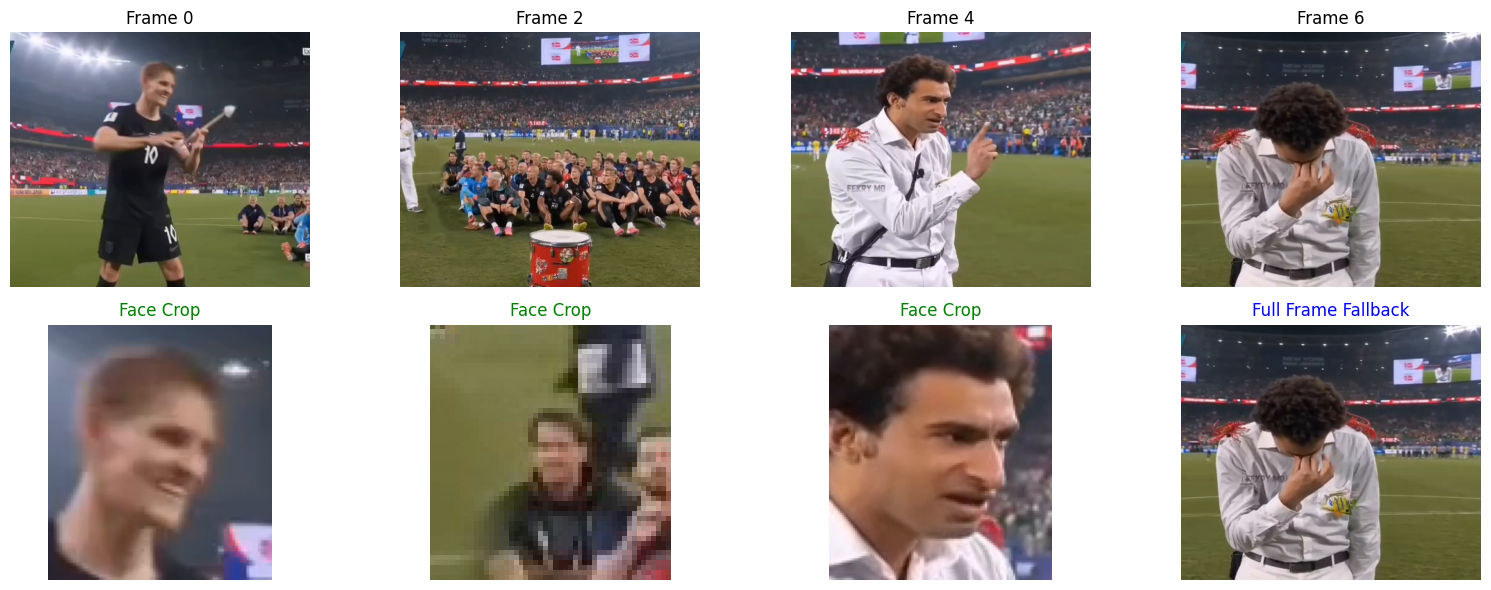

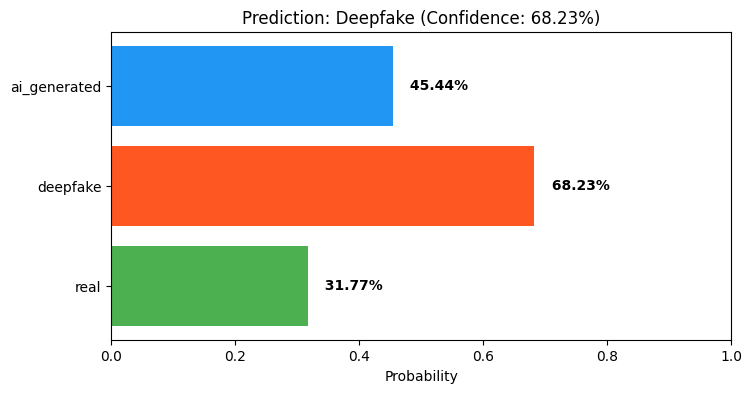

{
  "predicted_label": "Deepfake",
  "confidence": 0.6822796165943146,
  "scores": {
    "real": 0.3177203834056854,
    "deepfake": 0.6822796165943146,
    "ai_generated": 0.4543856531797376
  },
  "fired": {
    "deepfake": true,
    "ai_generated": false
  },
  "metadata": {
    "avg_deepfake_prob": 0.6822796165943146,
    "avg_aigc_prob": 0.4543856531797376,
    "percentage_faces_detected": 71.42857142857143,
    "n_frames": 7
  }
}


In [19]:
import json

# UPDATE THIS PATH TO YOUR TEST VIDEO
test_video_path = "/content/AI-generated_video2.mp4"

if os.path.exists(test_video_path):
    result, frames, processed_images, faces_detected = analyze_video_xor(test_video_path, n_frames=8)
    print("=" * 50)
    print(f"VERDICT     : {result['predicted_label']}")
    print(f"CONFIDENCE  : {result['confidence']:.2%}")
    print(f"Avg DF Prob : {result['metadata']['avg_deepfake_prob']:.2%}")
    print(f"Avg AI Prob : {result['metadata']['avg_aigc_prob']:.2%}")
    print(f"Faces Found : {result['metadata']['percentage_faces_detected']:.1f}% of frames")
    print(f"Fired       : {result['fired']}")
    print("=" * 50)
    print(json.dumps(result, indent=2))

    plot_results(result, frames, processed_images, faces_detected)
else:
    print(f"Please replace the path '{test_video_path}' with a real local path to a test video file.")


Successfully extracted 1 frames from /content/fake image.jpg
YuNet detected faces in 1/1 frames (100.0%)
Running Deepfake model inference...
Running AI-vs-Human model inference...
VERDICT     : AI-Generated
CONFIDENCE  : 100.00%
Avg DF Prob : 66.58%
Avg AI Prob : 100.00%
Faces Found : 100.0% of frames
Fired       : {'deepfake': True, 'ai_generated': True}
{
  "predicted_label": "AI-Generated",
  "confidence": 0.9999979734420776,
  "scores": {
    "real": 2.0265579223632812e-06,
    "deepfake": 0.6658351421356201,
    "ai_generated": 0.9999979734420776
  },
  "fired": {
    "deepfake": true,
    "ai_generated": true
  },
  "metadata": {
    "avg_deepfake_prob": 0.6658351421356201,
    "avg_aigc_prob": 0.9999979734420776,
    "percentage_faces_detected": 100.0,
    "n_frames": 1
  }
}


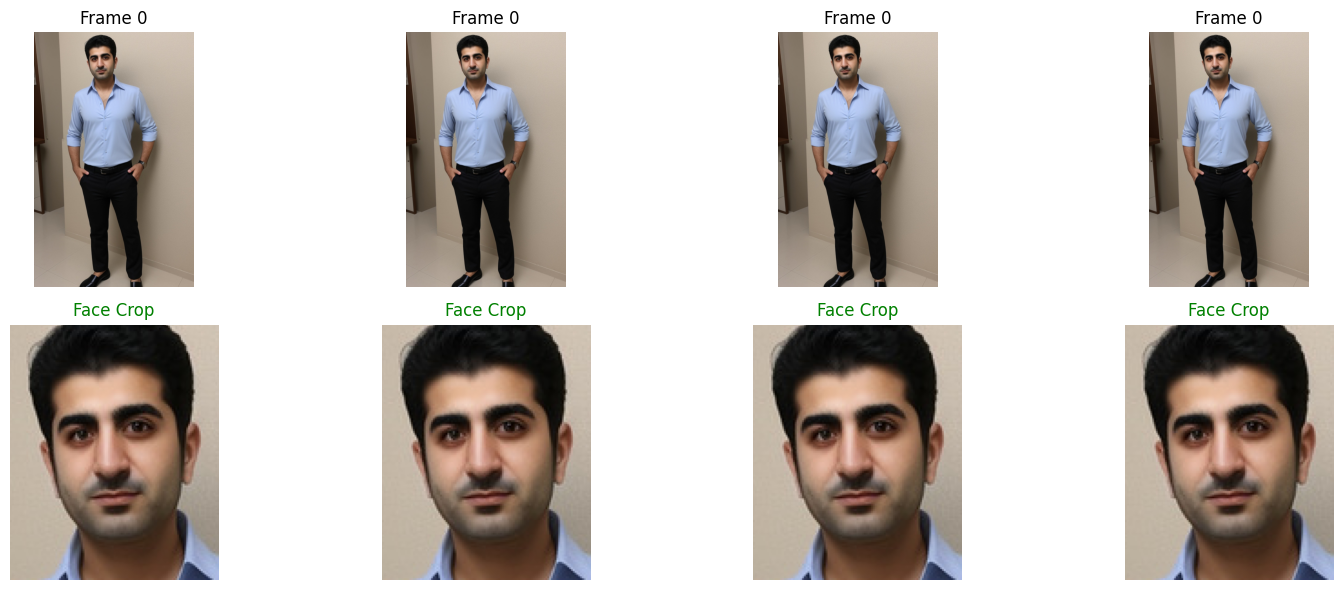

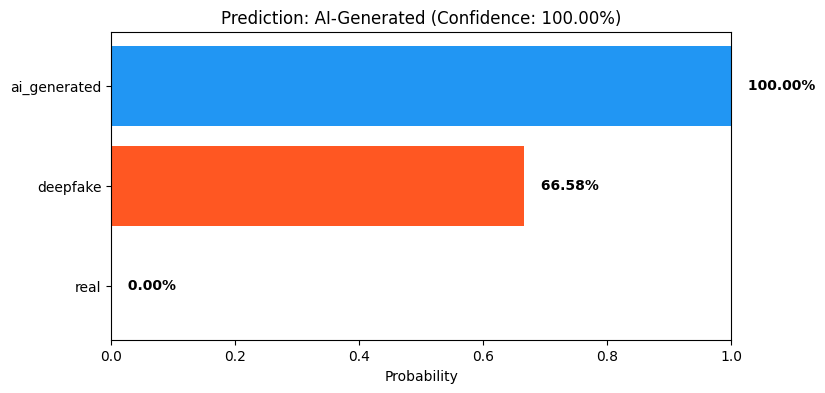

{
  "predicted_label": "AI-Generated",
  "confidence": 0.9999979734420776,
  "scores": {
    "real": 2.0265579223632812e-06,
    "deepfake": 0.6658351421356201,
    "ai_generated": 0.9999979734420776
  },
  "fired": {
    "deepfake": true,
    "ai_generated": true
  },
  "metadata": {
    "avg_deepfake_prob": 0.6658351421356201,
    "avg_aigc_prob": 0.9999979734420776,
    "percentage_faces_detected": 100.0,
    "n_frames": 1
  }
}


In [20]:
import json

# UPDATE THIS PATH TO YOUR TEST VIDEO
test_video_path = "/content/fake image.jpg"

if os.path.exists(test_video_path):
    result, frames, processed_images, faces_detected = analyze_video_xor(test_video_path, n_frames=8)
    print("=" * 50)
    print(f"VERDICT     : {result['predicted_label']}")
    print(f"CONFIDENCE  : {result['confidence']:.2%}")
    print(f"Avg DF Prob : {result['metadata']['avg_deepfake_prob']:.2%}")
    print(f"Avg AI Prob : {result['metadata']['avg_aigc_prob']:.2%}")
    print(f"Faces Found : {result['metadata']['percentage_faces_detected']:.1f}% of frames")
    print(f"Fired       : {result['fired']}")
    print("=" * 50)
    print(json.dumps(result, indent=2))

    plot_results(result, frames, processed_images, faces_detected)
else:
    print(f"Please replace the path '{test_video_path}' with a real local path to a test video file.")


Successfully extracted 1 frames from /content/fake image2.jpg
YuNet detected faces in 1/1 frames (100.0%)
Running Deepfake model inference...
Running AI-vs-Human model inference...
VERDICT     : AI-Generated
CONFIDENCE  : 99.92%
Avg DF Prob : 66.31%
Avg AI Prob : 99.92%
Faces Found : 100.0% of frames
Fired       : {'deepfake': True, 'ai_generated': True}
{
  "predicted_label": "AI-Generated",
  "confidence": 0.9992324113845825,
  "scores": {
    "real": 0.0007675886154174805,
    "deepfake": 0.6630510687828064,
    "ai_generated": 0.9992324113845825
  },
  "fired": {
    "deepfake": true,
    "ai_generated": true
  },
  "metadata": {
    "avg_deepfake_prob": 0.6630510687828064,
    "avg_aigc_prob": 0.9992324113845825,
    "percentage_faces_detected": 100.0,
    "n_frames": 1
  }
}


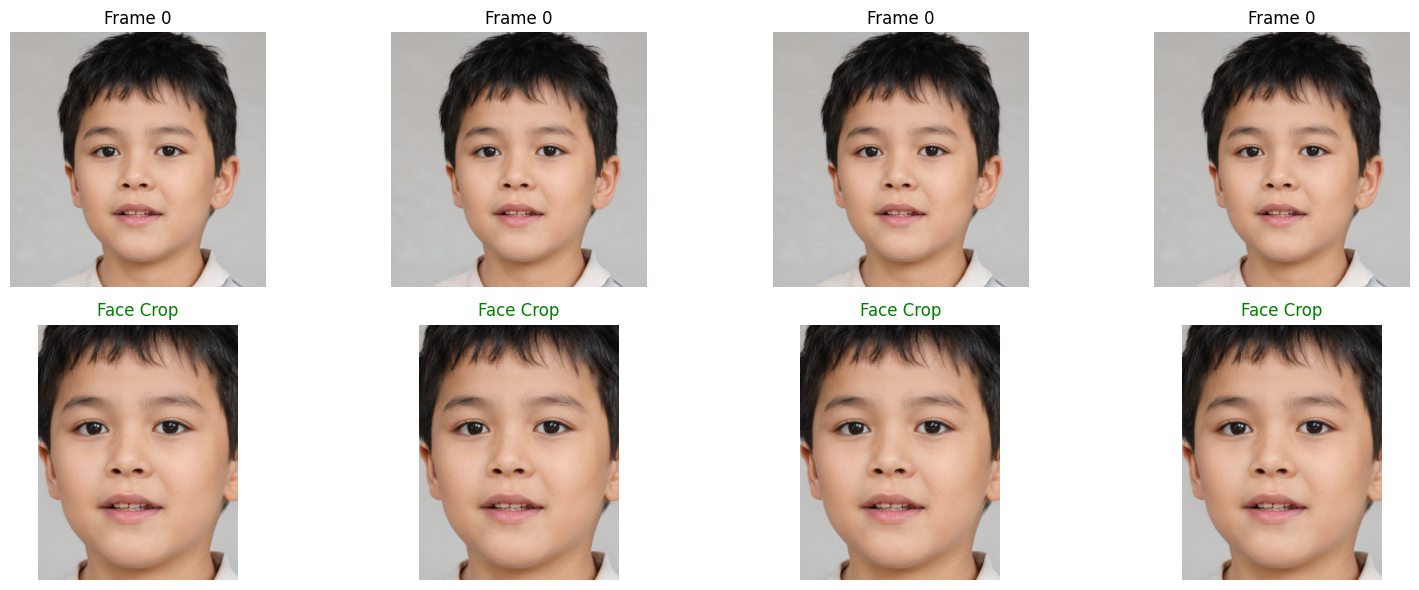

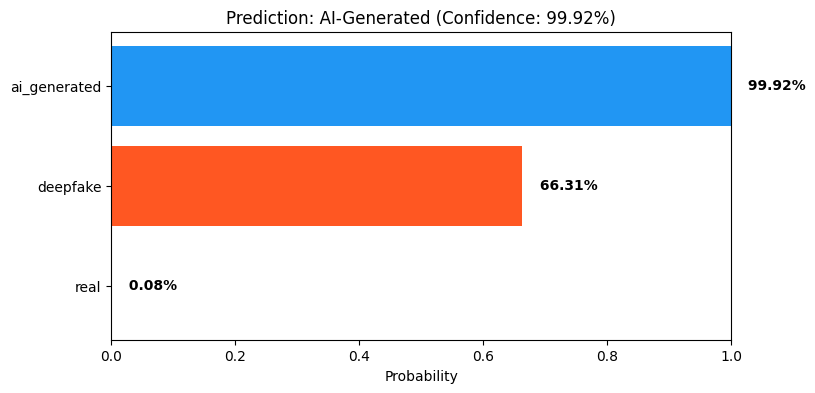

{
  "predicted_label": "AI-Generated",
  "confidence": 0.9992324113845825,
  "scores": {
    "real": 0.0007675886154174805,
    "deepfake": 0.6630510687828064,
    "ai_generated": 0.9992324113845825
  },
  "fired": {
    "deepfake": true,
    "ai_generated": true
  },
  "metadata": {
    "avg_deepfake_prob": 0.6630510687828064,
    "avg_aigc_prob": 0.9992324113845825,
    "percentage_faces_detected": 100.0,
    "n_frames": 1
  }
}


In [21]:
# UPDATE THIS PATH TO YOUR TEST VIDEO
test_video_path = "/content/fake image2.jpg"

if os.path.exists(test_video_path):
    result, frames, processed_images, faces_detected = analyze_video_xor(test_video_path, n_frames=8)
    print("=" * 50)
    print(f"VERDICT     : {result['predicted_label']}")
    print(f"CONFIDENCE  : {result['confidence']:.2%}")
    print(f"Avg DF Prob : {result['metadata']['avg_deepfake_prob']:.2%}")
    print(f"Avg AI Prob : {result['metadata']['avg_aigc_prob']:.2%}")
    print(f"Faces Found : {result['metadata']['percentage_faces_detected']:.1f}% of frames")
    print(f"Fired       : {result['fired']}")
    print("=" * 50)
    print(json.dumps(result, indent=2))

    plot_results(result, frames, processed_images, faces_detected)
else:
    print(f"Please replace the path '{test_video_path}' with a real local path to a test video file.")


Successfully extracted 8 frames from /content/real1.mp4
YuNet detected faces in 0/8 frames (0.0%)
Running Deepfake model inference...
Running AI-vs-Human model inference...
VERDICT     : AI-Generated
CONFIDENCE  : 62.62%
Avg DF Prob : 0.00%
Avg AI Prob : 62.62%
Faces Found : 0.0% of frames
Fired       : {'deepfake': False, 'ai_generated': True}
{
  "predicted_label": "AI-Generated",
  "confidence": 0.6262257567723282,
  "scores": {
    "real": 0.37377424322767183,
    "deepfake": 0.0,
    "ai_generated": 0.6262257567723282
  },
  "fired": {
    "deepfake": false,
    "ai_generated": true
  },
  "metadata": {
    "avg_deepfake_prob": 0.0,
    "avg_aigc_prob": 0.6262257567723282,
    "percentage_faces_detected": 0.0,
    "n_frames": 8
  }
}


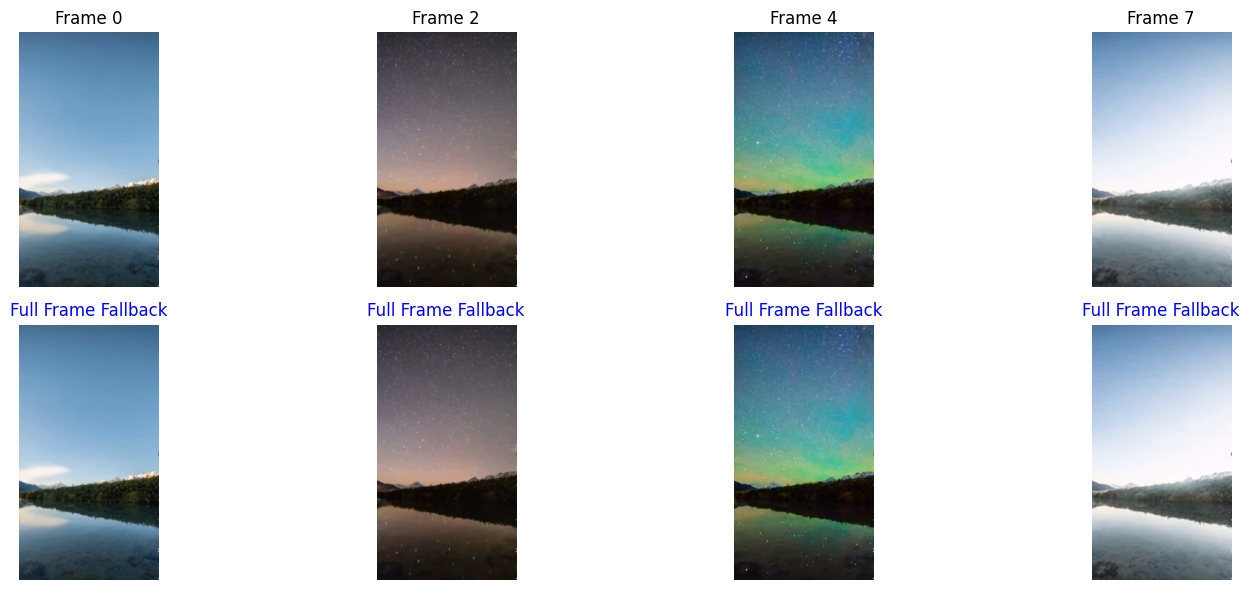

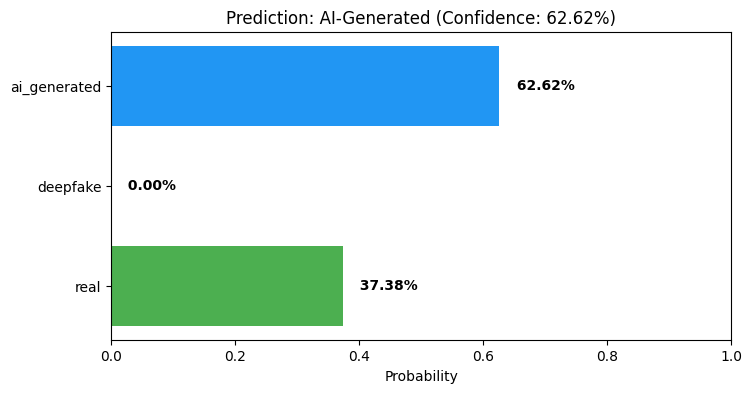

{
  "predicted_label": "AI-Generated",
  "confidence": 0.6262257567723282,
  "scores": {
    "real": 0.37377424322767183,
    "deepfake": 0.0,
    "ai_generated": 0.6262257567723282
  },
  "fired": {
    "deepfake": false,
    "ai_generated": true
  },
  "metadata": {
    "avg_deepfake_prob": 0.0,
    "avg_aigc_prob": 0.6262257567723282,
    "percentage_faces_detected": 0.0,
    "n_frames": 8
  }
}


In [22]:
# UPDATE THIS PATH TO YOUR TEST VIDEO
test_video_path = "/content/real1.mp4"

if os.path.exists(test_video_path):
    result, frames, processed_images, faces_detected = analyze_video_xor(test_video_path, n_frames=8)
    print("=" * 50)
    print(f"VERDICT     : {result['predicted_label']}")
    print(f"CONFIDENCE  : {result['confidence']:.2%}")
    print(f"Avg DF Prob : {result['metadata']['avg_deepfake_prob']:.2%}")
    print(f"Avg AI Prob : {result['metadata']['avg_aigc_prob']:.2%}")
    print(f"Faces Found : {result['metadata']['percentage_faces_detected']:.1f}% of frames")
    print(f"Fired       : {result['fired']}")
    print("=" * 50)
    print(json.dumps(result, indent=2))

    plot_results(result, frames, processed_images, faces_detected)
else:
    print(f"Please replace the path '{test_video_path}' with a real local path to a test video file.")
